# BANA205 Final Project: Spotify Churn Analysis 
Team 10A: Claudia Garcia, Nathacia N, Ernesto Mata, Qitong Ou, Tony Liang 

## Technical Appendix Overview

This notebook documents the full analytics process for our Spotify churn project. It includes:
- Data loading and basic checks
- Data cleaning and feature preparation
- K-means clustering to segment listeners based on behavior
- Robustness checks for the clustering model
- A multilinear regression model to quantify the impact of key features on churn

## Importing packages and Dataset

We first import Python packages for data manipulation, visualization, clustering, and regression. Then we load the Spotify churn dataset, which contains user-level information on listening behavior, engagement, and whether the user churned.

In [6]:
# importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scaling for K-means
from sklearn.preprocessing import StandardScaler 

# clustering
from sklearn.cluster import KMeans

# regression model
from sklearn.linear_model import LinearRegression

# train/test split
from sklearn.model_selection import train_test_split  

# regression evaluation
from sklearn.metrics import mean_squared_error, r2_score  


In [7]:
# importing dataset
spotify_df = pd.read_csv("spotify_churn_dataset.csv")
spotify_df.head()

,user_id,subscription_type,country,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login,churned
0,user_1,Premium,US,134.9,4,Electronic,6,0,1,0
1,user_2,Premium,PK,165.7,5,Pop,8,0,12,0
2,user_3,Free,DE,45.9,3,Classical,3,0,3,0
3,user_4,Premium,PK,106.0,0,Jazz,7,0,3,0
4,user_5,Premium,US,89.6,5,Country,2,1,6,0


## Data Cleaning

In this section we check the raw dataset for missing values, duplicates, and obvious data issues. We then correct invalid values where needed so that the clustering and regression models are based on realistic data.

In [8]:
# checking for missing values
spotify_df.isnull().sum()

user_id                  0
subscription_type        0
country                  0
avg_daily_minutes        0
number_of_playlists      0
top_genre                0
skips_per_day            0
support_tickets          0
days_since_last_login    0
churned                  0
dtype: int64

In [9]:
# checking for duplicates
spotify_df.duplicated().sum()

np.int64(0)

In [10]:
# data
spotify_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
avg_daily_minutes,1000.0,97.44,42.92,-37.2,65.9,97.9,129.75,237.8
number_of_playlists,1000.0,3.43,2.32,0.0,1.0,3.0,5.00,10.0
skips_per_day,1000.0,4.63,2.78,0.0,3.0,5.0,6.00,14.0
support_tickets,1000.0,0.23,0.51,0.0,0.0,0.0,0.00,2.0
days_since_last_login,1000.0,9.50,9.74,0.0,2.0,7.0,14.00,58.0
churned,1000.0,0.19,0.39,0.0,0.0,0.0,0.00,1.0


In [11]:
# correcting negative value in "avg_daily_minutes"
# all negative minutes will be replaced with 0
spotify_df["avg_daily_minutes"] = spotify_df["avg_daily_minutes"].clip(lower=0)
spotify_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
avg_daily_minutes,1000.0,97.57,42.59,0.0,65.9,97.9,129.75,237.8
number_of_playlists,1000.0,3.43,2.32,0.0,1.0,3.0,5.00,10.0
skips_per_day,1000.0,4.63,2.78,0.0,3.0,5.0,6.00,14.0
support_tickets,1000.0,0.23,0.51,0.0,0.0,0.0,0.00,2.0
days_since_last_login,1000.0,9.50,9.74,0.0,2.0,7.0,14.00,58.0
churned,1000.0,0.19,0.39,0.0,0.0,0.0,0.00,1.0


## Analysis I - K-Means Clustering

We use K-means clustering to segment Spotify users into behavior-based groups. The goal is to identify listener profiles that differ in engagement and churn risk, which can later inform targeted retention strategies.

In [12]:
# preparing the clustering dataframe
cluster_vars = ["avg_daily_minutes", "number_of_playlists", "skips_per_day", "support_tickets", "days_since_last_login"]

X = spotify_df[cluster_vars]

# scaling data for K-means


We build the clustering dataset using behavioral and engagement variables:
- `avg_daily_minutes`: how much users listen per day
- `number_of_playlists`: how curated their listening is
- `skips_per_day`: tendency to skip songs
- `support_tickets`: signals of friction or issues
- `days_since_last_login`: recency of activity

These features are chosen because they capture different dimensions of user engagement that are likely related to churn.
Demographic information is important but will be used mainly to explain clustering results. 

In [13]:
# scaling data for K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

We scale the features using `StandardScaler` so that all variables contribute equally to the distance calculation in K-means. This prevents variables with larger numeric ranges from dominating the clusters.

In [38]:
# aesthetics - dark mode
plt.style.use('dark_background')

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Inertia values:
k = 2: 4026.39
k = 3: 3571.55
k = 4: 2923.34
k = 5: 2480.01
k = 6: 2306.43
k = 7: 2237.50
k = 8: 2048.69
k = 9: 1960.31


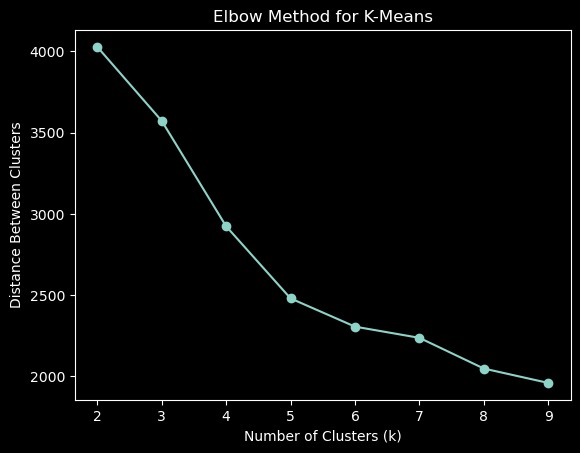

In [39]:
# elbow method - number of clusters
inertia = []
k_range = range(2,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# inertia values
print("Inertia values:")
for k, val in zip(k_range, inertia):
    print(f"k = {k}: {val:.2f}")

# plotting elbow method for k means
plt.plot(k_range, inertia, marker= 'o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distance Between Clusters")
plt.title("Elbow Method for K-Means")
plt.show()

We run K-means for different values of k and plot the inertia (within-cluster sum of squares). The curve shows a clear elbow at k = 4: after four clusters, the marginal gain in inertia reduction becomes much smaller. Based on this pattern, we select **k = 4** as the number of clusters for our listener segments.

In [15]:
# running k-means with 4 clusters (k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
spotify_df['cluster'] = kmeans.fit_predict(X_scaled)
spotify_df['cluster']

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


0      2
1      2
2      0
3      1
4      3
      ..
995    0
996    2
997    2
998    0
999    1
Name: cluster, Length: 1000, dtype: int32

In [16]:
# assigning profiles to clusters
cluster_profile = spotify_df.groupby("cluster")[cluster_vars].mean().round(2)
cluster_profile

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login
cluster,,,,,
0,59.86,1.93,3.03,0.01,9.66
1,98.03,2.61,7.86,0.01,9.70
2,128.74,5.55,3.68,0.01,9.51
3,101.26,3.21,4.44,1.24,8.96


In [17]:
# cluster names
segment_names = {
    0: "Casual Listeners",
    1: "Explorers & Skippers",
    2: "Committed Listeners",
    3: "Frustrated Users"
}

spotify_df["segment"] = spotify_df["cluster"].map(segment_names)

In [18]:
# putting churn patterns on each cluster
cluster_churn = spotify_df.groupby("cluster")["churned"].mean().round(2)
cluster_churn

cluster
0    0.29
1    0.12
2    0.06
3    0.34
Name: churned, dtype: float64

In [19]:
# putting churn patterns on each cluster with segment name
cluster_churn = spotify_df.groupby("segment")["churned"].mean().round(2)
print("Spotify Listener Profiles and Churn Patterns")
cluster_churn

Spotify Listener Profiles and Churn Patterns


segment
Casual Listeners        0.29
Committed Listeners     0.06
Explorers & Skippers    0.12
Frustrated Users        0.34
Name: churned, dtype: float64

These results allow us to interpret each segment as a distinct listener profile with a different churn risk. This forms the basis for our managerial recommendations about which groups to prioritize for retention efforts.

## Visualizations

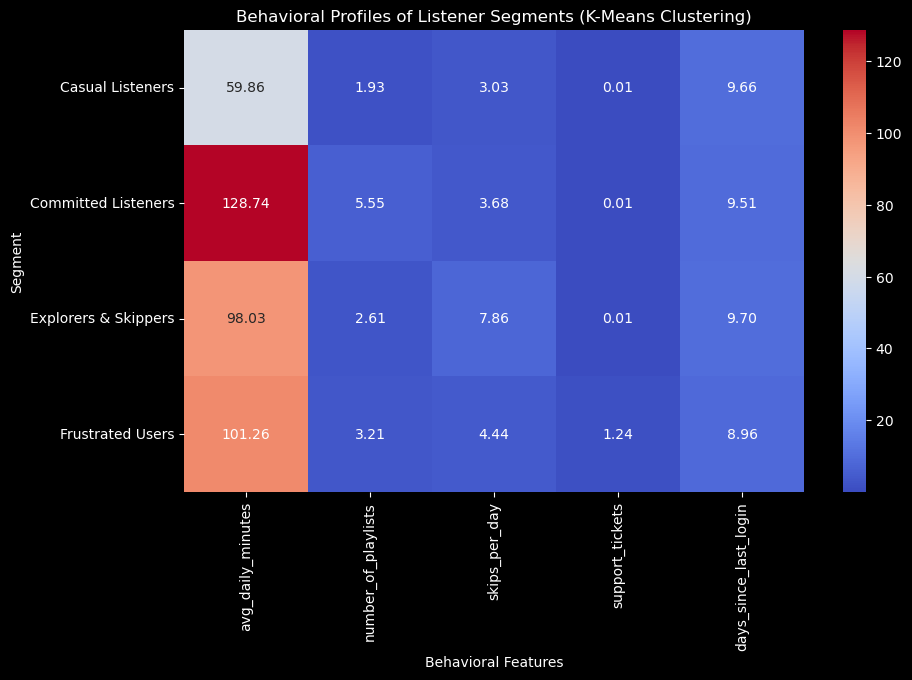

In [40]:
# Clusters in graph (heatmap)
cluster_means = spotify_df.groupby("segment")[[
    "avg_daily_minutes", 
    "number_of_playlists", 
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]].mean()

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Behavioral Profiles of Listener Segments (K-Means Clustering)")
plt.xlabel("Behavioral Features")
plt.ylabel("Segment")
plt.show()

K-means clustering reveals four distinct listener profiles that differ clearly in engagement, playlist behavior, skipping habits, and support interactions

C:\Users\claud\AppData\Local\Temp\ipykernel_24756\1294566870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


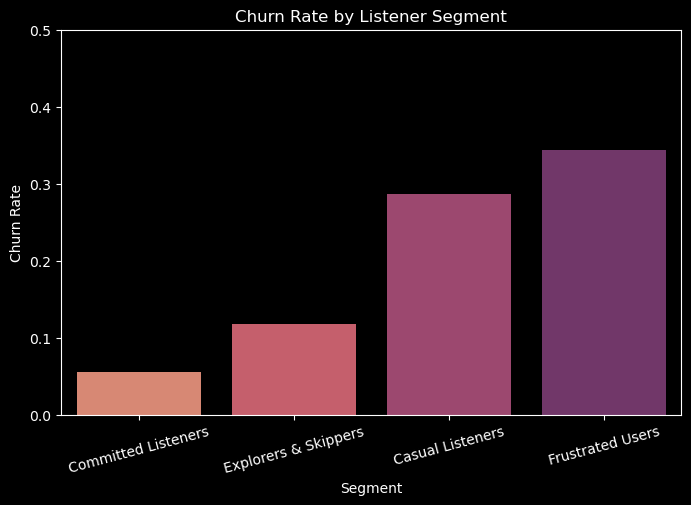

In [41]:
# Churn Rate by Segment
cluster_churn = spotify_df.groupby("segment")["churned"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(
    x=cluster_churn.index,
    y=cluster_churn.values,
    palette='flare'
)
plt.title("Churn Rate by Listener Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.5)
plt.xticks(rotation=15)
plt.show()

In [22]:
cluster_map = {
    0: "Casual Listeners",
    1: "Explorers & Skippers",
    2: "Committed Listeners",
    3: "Frustrated Users"
}
spotify_df["segment"] = spotify_df["cluster"].map(cluster_map)

C:\Users\claud\AppData\Local\Temp\ipykernel_24756\1622140975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


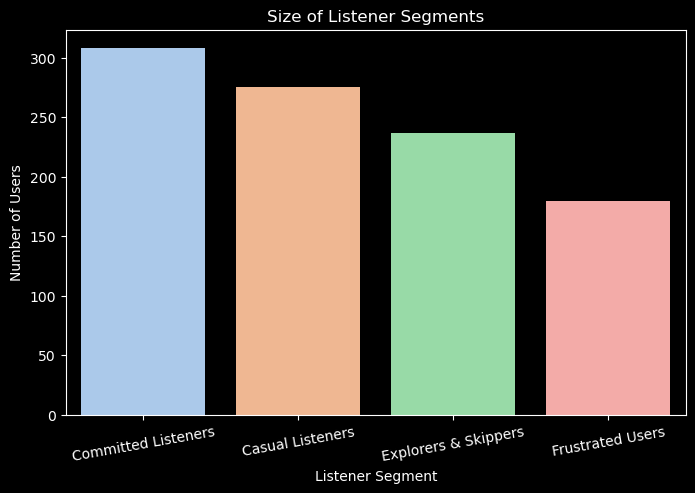

In [42]:
#Size of Listener Segments

plt.figure(figsize=(8,5))
sns.countplot(
    data=spotify_df,
    x='segment',
    palette='pastel'
)
plt.title("Size of Listener Segments")
plt.xlabel("Listener Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=10)
plt.show()

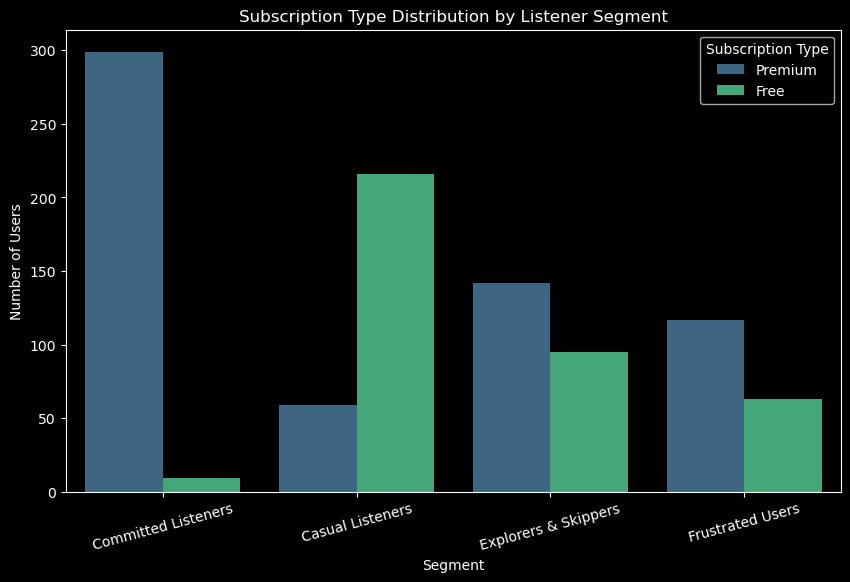

In [43]:
# Segment Composition by Subscription Type
plt.figure(figsize=(10,6))
sns.countplot(
    data=spotify_df,
    x='segment',
    hue='subscription_type',
    palette='viridis'
)
plt.title("Subscription Type Distribution by Listener Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Users")
plt.legend(title="Subscription Type")
plt.xticks(rotation=15)
plt.show()

#### Additional Visualizations

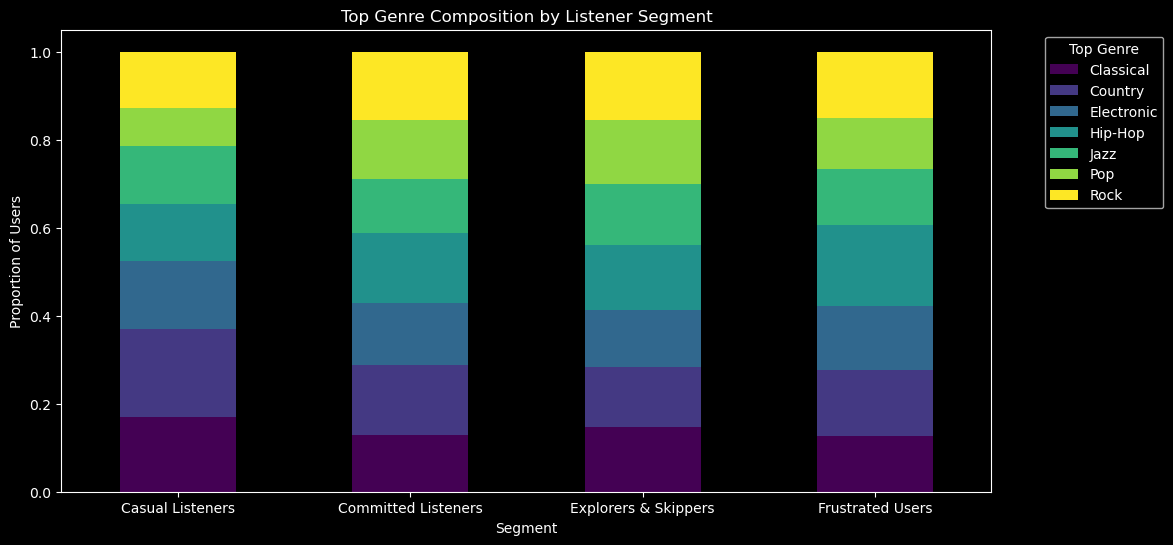

In [44]:
# Segment Composition by Top Music Genre

genre_pct = (
    spotify_df
    .groupby(['segment', 'top_genre'])
    .size()
    .reset_index(name='count')
)

genre_pct['percent'] = genre_pct['count'] / genre_pct.groupby('segment')['count'].transform('sum')

genre_pivot = genre_pct.pivot(index='segment', columns='top_genre', values='percent').fillna(0)

genre_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title("Top Genre Composition by Listener Segment")
plt.ylabel("Proportion of Users")
plt.xlabel("Segment")
plt.xticks(rotation=0)
plt.legend(title='Top Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


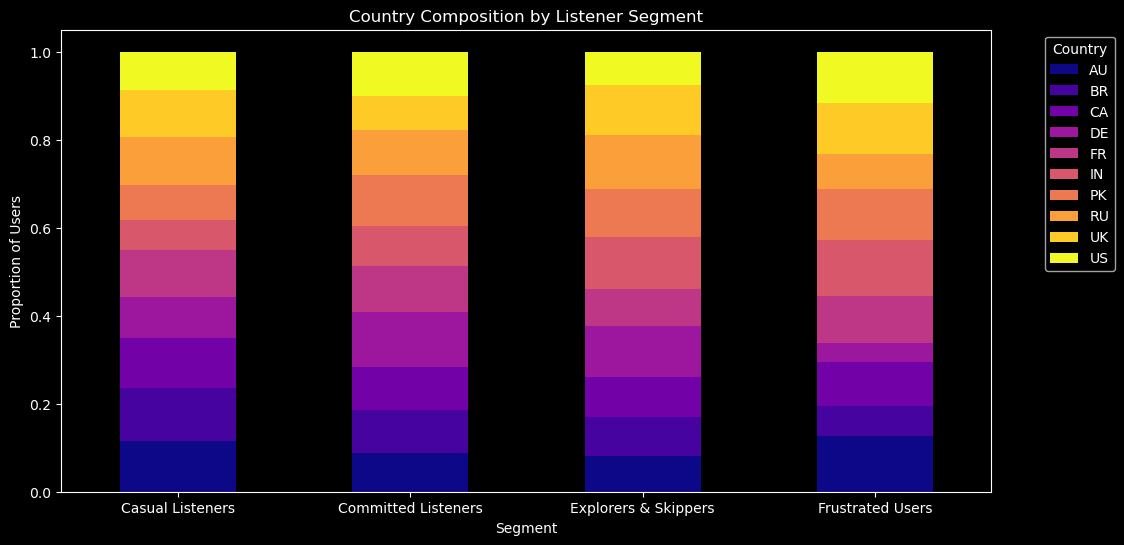

In [45]:
# Segment Composition by Country
country_pct = (
    spotify_df
    .groupby(['segment', 'country'])
    .size()
    .reset_index(name='count')
)

country_pct['percent'] = country_pct['count'] / country_pct.groupby('segment')['count'].transform('sum')

country_pivot = country_pct.pivot(index='segment', columns='country', values='percent').fillna(0)

country_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='plasma'
)

plt.title("Country Composition by Listener Segment")
plt.ylabel("Proportion of Users")
plt.xlabel("Segment")
plt.xticks(rotation=0)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Robustness Checks

#### Robustness Check 1: Changing the random initial centroid "seed"

We re-run K-means for k = 4 with a different random seed and compare the new labels to the original ones. The high agreement rate indicates that the cluster structure is stable and does not depend heavily on the initial random centroids.

In [27]:
kmeans_test = KMeans(n_clusters=4, random_state=123)
test_labels = kmeans_test.fit_predict(X_scaled)

# compare agreement 
agreement = (spotify_df['cluster'] == test_labels).mean()
agreement

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


np.float64(0.337)

##### Trying k = 3 and Robustness

With k = 3, clusters merge into broader groups and some nuance in churn patterns is lost. This suggests that three clusters may be too coarse for our business question.

In [28]:
# 1. Fit k = 3 once
kmeans3 = KMeans(n_clusters=3, random_state=42)
spotify_df["cluster_k3"] = kmeans3.fit_predict(X_scaled)

# 2. Look at behavior per cluster
spotify_df.groupby("cluster_k3")[cluster_vars].mean().round(2)

# 3. Look at churn per cluster
spotify_df.groupby("cluster_k3")["churned"].mean().round(2)

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


cluster_k3
0    0.32
1    0.16
2    0.08
Name: churned, dtype: float64

In [29]:
kmeans3_test = KMeans(n_clusters=3, random_state=123)
test_labels3 = kmeans3_test.fit_predict(X_scaled)

# compare agreement 
agreement_k3 = (spotify_df['cluster_k3'] == test_labels3).mean()
agreement_k3

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


np.float64(0.472)

##### Trying k = 5 and Robustness

With k = 5, we see more fragmented segments with smaller group sizes. This adds complexity without a clear gain in interpretability or churn separation. Taken together, these checks support our choice of k = 4.

In [30]:
# Try k = 5
kmeans5 = KMeans(n_clusters=5, random_state=42)
spotify_df["cluster_k5"] = kmeans5.fit_predict(X_scaled)

# Behavior patterns
spotify_df.groupby("cluster_k5")[cluster_vars].mean().round(2)

# Churn rates
spotify_df.groupby("cluster_k5")["churned"].mean().round(2)

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


cluster_k5
0    0.27
1    0.09
2    0.03
3    0.33
4    0.29
Name: churned, dtype: float64

In [31]:
kmeans5_test = KMeans(n_clusters=5, random_state=123)
test_labels5 = kmeans5_test.fit_predict(X_scaled)

agreement_k5 = (spotify_df["cluster_k5"] == test_labels5).mean()
agreement_k5

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


np.float64(0.462)

#### Robustness Check 2: Removing most important variables

We re-estimate the clusters after removing one key variable at a time. The overall segment structure and churn patterns remain similar, which suggests that our results are not driven by a single feature. This strengthens confidence in the clustering solution.

In [32]:
# -variable 1 = avg_daily_minutes
vars_minus1 = ["number_of_playlists",
    "skips_per_day",
    "support_tickets",
    "days_since_last_login"
]

X_temp = spotify_df[vars_minus1]

# scaling
X_temp_scaled = scaler.fit_transform(X_temp)

# running kmeans, k = 4
kmeans_temp = KMeans(n_clusters=4, random_state=42)
labels_temp = kmeans_temp.fit_predict(X_temp_scaled)

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [33]:
# comparing
spotify_df["cluster_minus1"] = labels_temp
spotify_df.groupby("cluster_minus1")[vars_minus1].mean().round(2)

,number_of_playlists,skips_per_day,support_tickets,days_since_last_login
cluster_minus1,,,,
0,3.07,4.94,0.06,27.79
1,5.35,3.26,0.00,6.28
2,3.23,4.46,1.24,7.56
3,1.91,5.86,0.00,6.03


In [34]:
# -variable 2 = skips_per_day
vars_minus2 = ["avg_daily_minutes",
    "number_of_playlists",
    "support_tickets",
    "days_since_last_login"
]

X_temp = spotify_df[vars_minus2]

# scaling
X_temp_scaled = scaler.fit_transform(X_temp)

# running kmeans, k = 4
kmeans_temp = KMeans(n_clusters=4, random_state=42)
labels_temp = kmeans_temp.fit_predict(X_temp_scaled)

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [35]:
# comparing
spotify_df["cluster_minus2"] = labels_temp
spotify_df.groupby("cluster_minus2")[vars_minus2].mean().round(2)

,avg_daily_minutes,number_of_playlists,support_tickets,days_since_last_login
cluster_minus2,,,,
0,102.76,3.11,0.06,27.64
1,125.03,5.17,0.00,6.21
2,105.80,3.51,1.26,7.72
3,62.71,1.73,0.04,6.25


In [36]:
# -variable 3 = support_tickets
vars_minus3 = ["avg_daily_minutes",
    "number_of_playlists",
    "skips_per_day",
    "days_since_last_login"
]

X_temp = spotify_df[vars_minus3]

# scaling
X_temp_scaled = scaler.fit_transform(X_temp)

# running kmeans, k = 4
kmeans_temp = KMeans(n_clusters=4, random_state=42)
labels_temp = kmeans_temp.fit_predict(X_temp_scaled)

C:\Users\claud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [37]:
# comparing
spotify_df["cluster_minus3"] = labels_temp
spotify_df.groupby("cluster_minus3")[vars_minus3].mean().round(2)

,avg_daily_minutes,number_of_playlists,skips_per_day,days_since_last_login
cluster_minus3,,,,
0,59.76,1.73,2.78,7.68
1,95.80,2.62,7.61,6.42
2,127.75,5.58,3.63,6.57
3,107.45,3.37,5.03,29.85


## Analysis II - Multilinear Regression

In this section we use a multilinear regression model to quantify how strongly each variable is associated with churn. While clustering gives us segments, regression helps us measure the marginal effect of individual drivers such as engagement, skips, and support tickets.

### Defining variables

We set `churned` as the dependent variable and use behavioral and engagement features as independent variables. Boolean variables are dummy-encoded so they can be included in the regression model.

In [49]:
# dummy encoding for booleans
spotify_df2 = spotify_df[['avg_daily_minutes','number_of_playlists','skips_per_day', 'support_tickets', 'days_since_last_login','churned']].copy()
df_spotify_reg = pd.get_dummies(spotify_df2, drop_first=True)

In [50]:
df_spotify_reg #--> checking variables/attributes

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned
0,134.9,4,6,0,1,0
1,165.7,5,8,0,12,0
2,45.9,3,3,0,3,0
3,106.0,0,7,0,3,0
4,89.6,5,2,1,6,0
...,...,...,...,...,...,...
995,47.6,5,5,0,27,1
996,115.1,5,2,0,4,0
997,89.5,6,0,0,1,0
998,33.2,3,5,0,15,1


In [51]:
# dependent variable
y = df_spotify_reg["churned"]

# independent variables
X = df_spotify_reg.drop(columns=["churned"])

### Running the regression

In [52]:
reg = LinearRegression()
reg.fit(X, y)

r2 = reg.score(X, y)
r2

0.15323551970234572

The R² value summarizes how much of the variation in churn is explained by the model. We use this as a diagnostic to see whether the selected features capture a meaningful share of churn behavior.

### Coefficients Table

In [53]:
coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": reg.coef_.round(4)
}).sort_values("Coefficient", ascending=False)

coef_table

,Variable,Coefficient
3,support_tickets,0.1584
4,days_since_last_login,0.0063
0,avg_daily_minutes,-0.0025
2,skips_per_day,-0.0041
1,number_of_playlists,-0.0095


The coefficients table shows the direction and relative strength of each feature's association with churn. Positive coefficients indicate higher churn risk as the variable increases, while negative coefficients correspond to lower churn risk. This helps us translate the model into actionable insights for marketing and retention strategy.

### Visualizations

C:\Users\claud\AppData\Local\Temp\ipykernel_24756\2285309323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


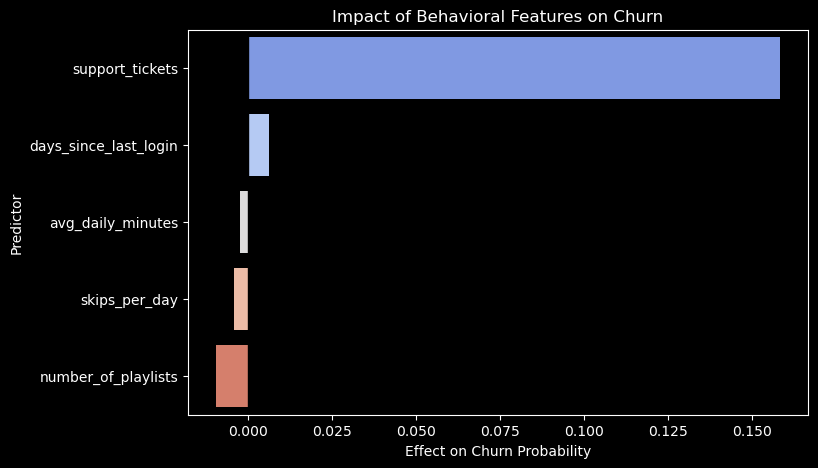

In [55]:
# Impact of Behavioral Variables on Churn
plt.figure(figsize=(8,5))
sns.barplot(
    data=coef_table,
    x="Coefficient",
    y="Variable",
    palette="coolwarm"
)
plt.axvline(0, color='black', linewidth=1)
plt.title("Impact of Behavioral Features on Churn")
plt.xlabel("Effect on Churn Probability")
plt.ylabel("Predictor")
plt.show()
